In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
%precision %.4f
import warnings
warnings.filterwarnings('ignore')

In [8]:
df = pd.read_csv('titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [9]:
print("Размер датасета:", df.shape)
print("\nТипы данных:")
print(df.dtypes)
print("\nОписание числовых признаков:")
df.describe()

Размер датасета: (891, 12)

Типы данных:
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

Описание числовых признаков:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Задача: предсказать, выжил ли пассажир (Survived = 0 или 1),
используя признаки: Pclass, Sex, Age, SibSp, Parch, Fare, Embarked.
Это задача бинарной классификации.

In [10]:
# Age: заполняем медианой по классу билета (осмысленно — богатые пассажиры старше)
df['Age'] = df.groupby('Pclass')['Age'].transform(lambda x: x.fillna(x.median()))

# Embarked: заполняем самым частым значением
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Cabin: слишком много пропусков (77%), удалим позже
print("Пропуски после чистки:")
print(df.isnull().sum())

Пропуски после чистки:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64


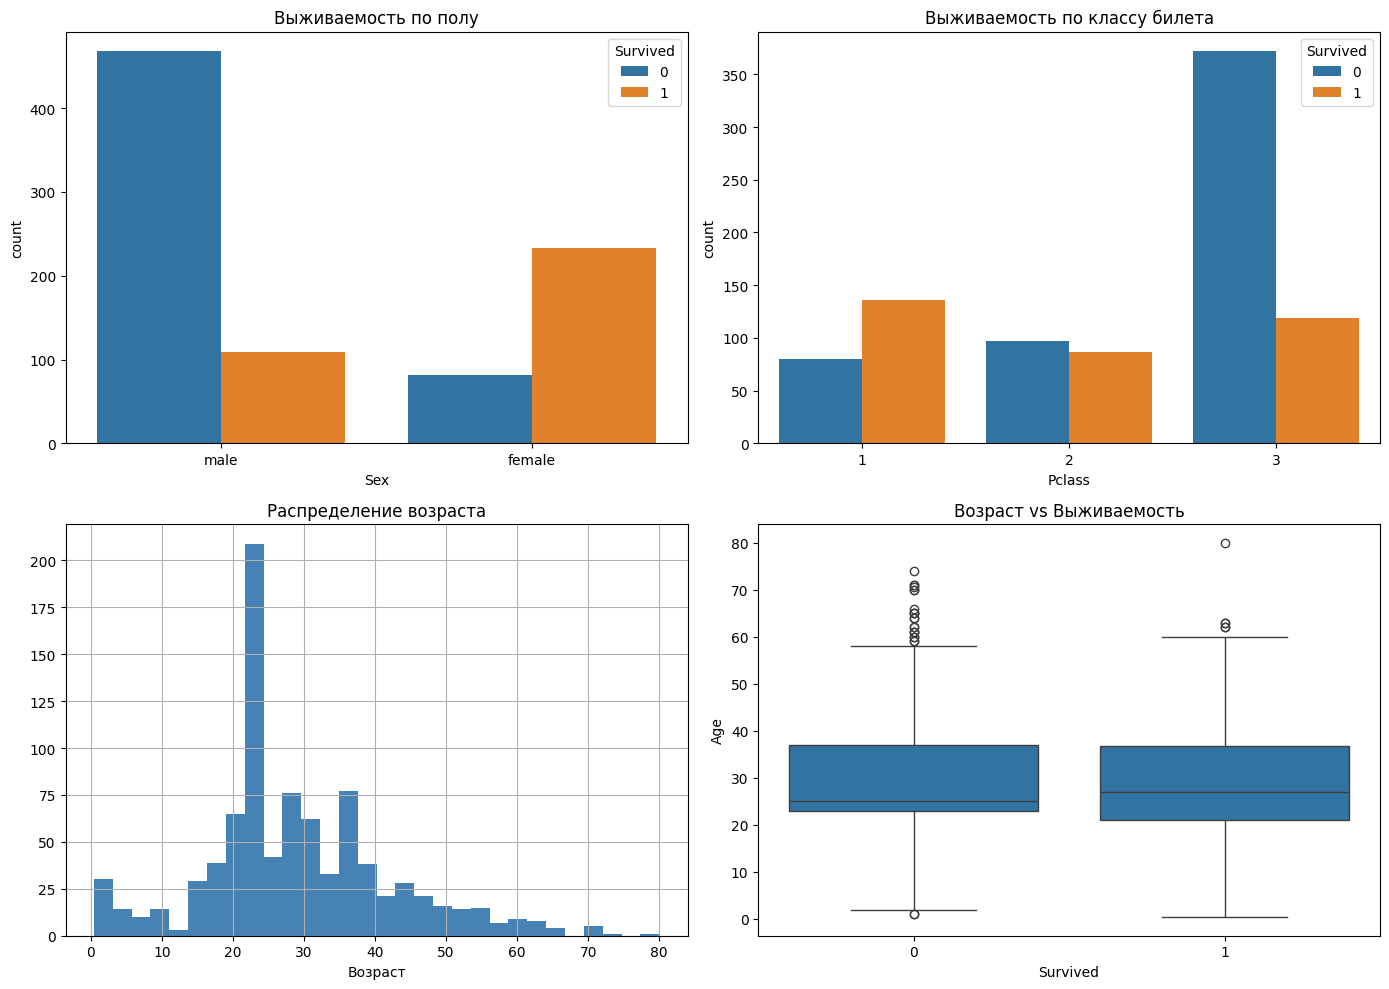

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Выживаемость по полу
sns.countplot(data=df, x='Sex', hue='Survived', ax=axes[0,0])
axes[0,0].set_title('Выживаемость по полу')

# Выживаемость по классу
sns.countplot(data=df, x='Pclass', hue='Survived', ax=axes[0,1])
axes[0,1].set_title('Выживаемость по классу билета')

# Распределение возраста
df['Age'].hist(bins=30, ax=axes[1,0], color='steelblue')
axes[1,0].set_title('Распределение возраста')
axes[1,0].set_xlabel('Возраст')

# Boxplot: возраст vs выживаемость
sns.boxplot(data=df, x='Survived', y='Age', ax=axes[1,1])
axes[1,1].set_title('Возраст vs Выживаемость')

plt.tight_layout()
plt.show()

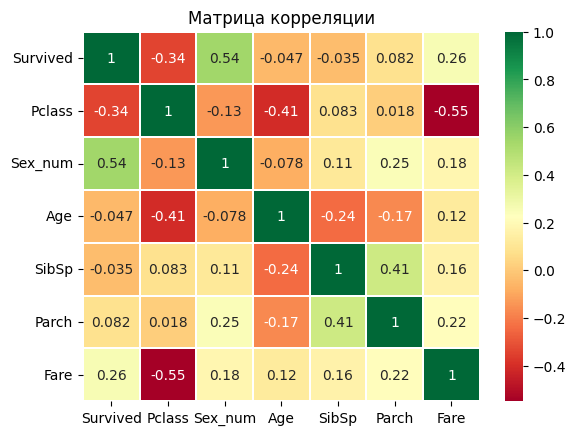

In [12]:
# Сначала переведём Sex в число для корреляции
df_corr = df.copy()
df_corr['Sex_num'] = df_corr['Sex'].map({'male': 0, 'female': 1})

numeric_cols = ['Survived', 'Pclass', 'Sex_num', 'Age', 'SibSp', 'Parch', 'Fare']
sns.heatmap(df_corr[numeric_cols].corr(), annot=True, cmap='RdYlGn', linewidths=0.2)
plt.title('Матрица корреляции')
plt.show()

In [13]:
# Новый признак: размер семьи
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# Новый признак: один ли пассажир
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

# Перевод Sex в числовой признак
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

# Перевод Embarked в числовой
df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

# Удаляем ненужные признаки
df.drop(['Name', 'Ticket', 'Cabin', 'PassengerId'], axis=1, inplace=True)

print("Итоговый датасет:")
df.head()

Итоговый датасет:


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone
0,0,3,0,22.0,1,0,7.2500,0,2,0
1,1,1,1,38.0,1,0,71.2833,1,2,0
2,1,3,1,26.0,0,0,7.9250,0,1,1
3,1,1,1,35.0,1,0,53.1000,0,2,0
4,0,3,0,35.0,0,0,8.0500,0,1,1
